In [31]:
import numpy as np
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from DESolver import DESolver

from problems_ODEs import ProblemsODE
from problems_PDEs import ProblemsPDE

import pickle
import os

import seaborn as sns
sns.set_context("talk", font_scale=1.25) # "talk"
TEND=0.5
#KAPPA=np.asarray([1e+03,2e+03])
KAPPA=np.asarray([1e+05,2e+05])
#KAPPA=np.asarray([0.,0.])
pde_problem_setup_base={'mx':200,
                        'n':2,
                        'Flux':'linear-advection',
                        'Flux_c':1.,
                        'BC':'periodic',
                        'x_min':0.,
                        'x_max':1.,
                        'kappa':KAPPA, 
                        'IC':'Test1',
                        's':np.asarray([0,1]),
                        'alpha':np.asarray([1,0]),
                        'alpha_i':np.asarray([0,10]),
                        'Flux_name':'FVStagVanLeer-k=1/3'}

#'alpha_i':np.asarray([1,1]),

#'1stOrderUpwindFV'
#'3rdOrderUpwindFD'
#'FVStagVanLeer-k=1'
#'FVStagVanLeer-k=1/3'
#         
FN_BASE="AdvReactTestConv_2S_ICERM2_"

CFL explicit = [1. 0.]
CFL implicit = [ 0. 10.]
Solving Advection Reaction 1D by using ARK-IMEX-Mix-2-2-c


/opt/local/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Mass ini = 0.9999999999999997 and mass end = 1.0000000000000893


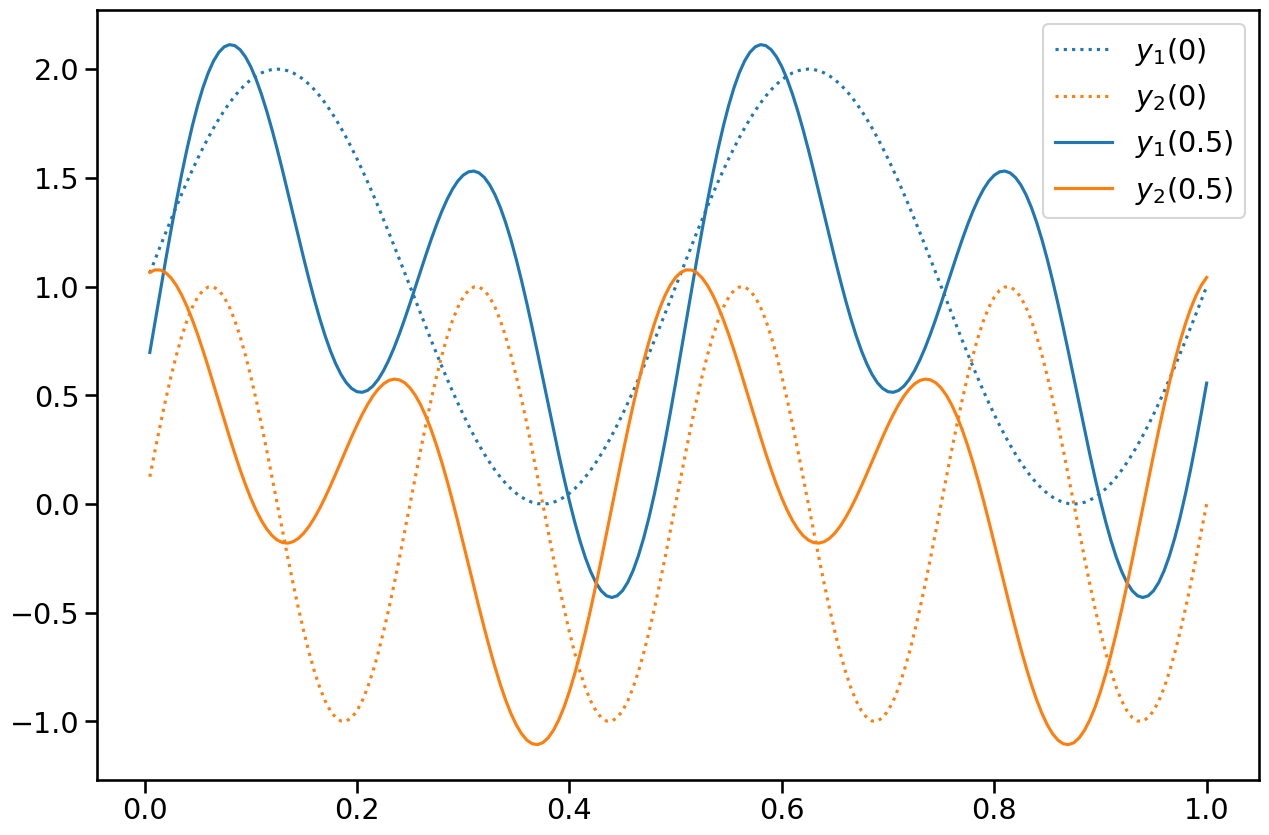

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[0.         0.         0.        ]
 [0.58578644 0.         0.        ]
 [0.5        0.5        0.        ]]
b =
[0.35355339 0.35355339 0.29289322]
c =
[0.         0.58578644 1.        ]
At =
[[0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.60355339 0.60355339 0.5       ]]
bt =
[0.35355339 0.35355339 0.29289322]
ct =
[0.         0.         1.70710678]
------------------------------------------


In [32]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup=pde_problem_setup_base.copy()

rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)

solver.set_method('ARK-IMEX-Mix-2-2-c')
#solver.set_method('ARK2e')
#solver.set_method('ARK-IMEX-MR4')
#solver.set_method('ARK-IMEX-Mix-1-1')


if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.005    
problem_setup['T_DURATION']['end']=TEND

CFL=[]
CFL.append(pde_problem_setup['alpha']*problem_setup['DT']/problem_setup['context']['dx'])
CFL.append(pde_problem_setup['alpha_i']*problem_setup['DT']/problem_setup['context']['dx'])
print("CFL explicit = {:}".format(CFL[0]))
print("CFL implicit = {:}".format(CFL[1]))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,_,_,_=solver.get_trajectory_GLEE()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))



#sol=u
unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))
y_end_mix22c=y_end.copy()
mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
hy1=plt.plot(x_coord,y_ini[0,:],':',label=r'$y_1(0)$')
hy2=plt.plot(x_coord,y_ini[1,:],':',label=r'$y_2(0)$')

plt.plot(x_coord,y_end[0,:],'-',color=hy1[0].get_color(),label=r'$y_1({:g})$'.format(t[-1]))
plt.plot(x_coord,y_end[1,:],'-',color=hy2[0].get_color(),label=r'$y_2({:g})$'.format(t[-1]))

plt.legend()
plt.show()

solver.view_complete_status()

ARK22c={'x_coord':x_coord,'y_end':y_end}


CFL explicit = [1. 0.]
CFL implicit = [ 0. 10.]
Solving Advection Reaction 1D by using ARK-IMEX-Mix-2-1-c
Mass ini = 0.9999999999999997 and mass end = 1.000000000000005


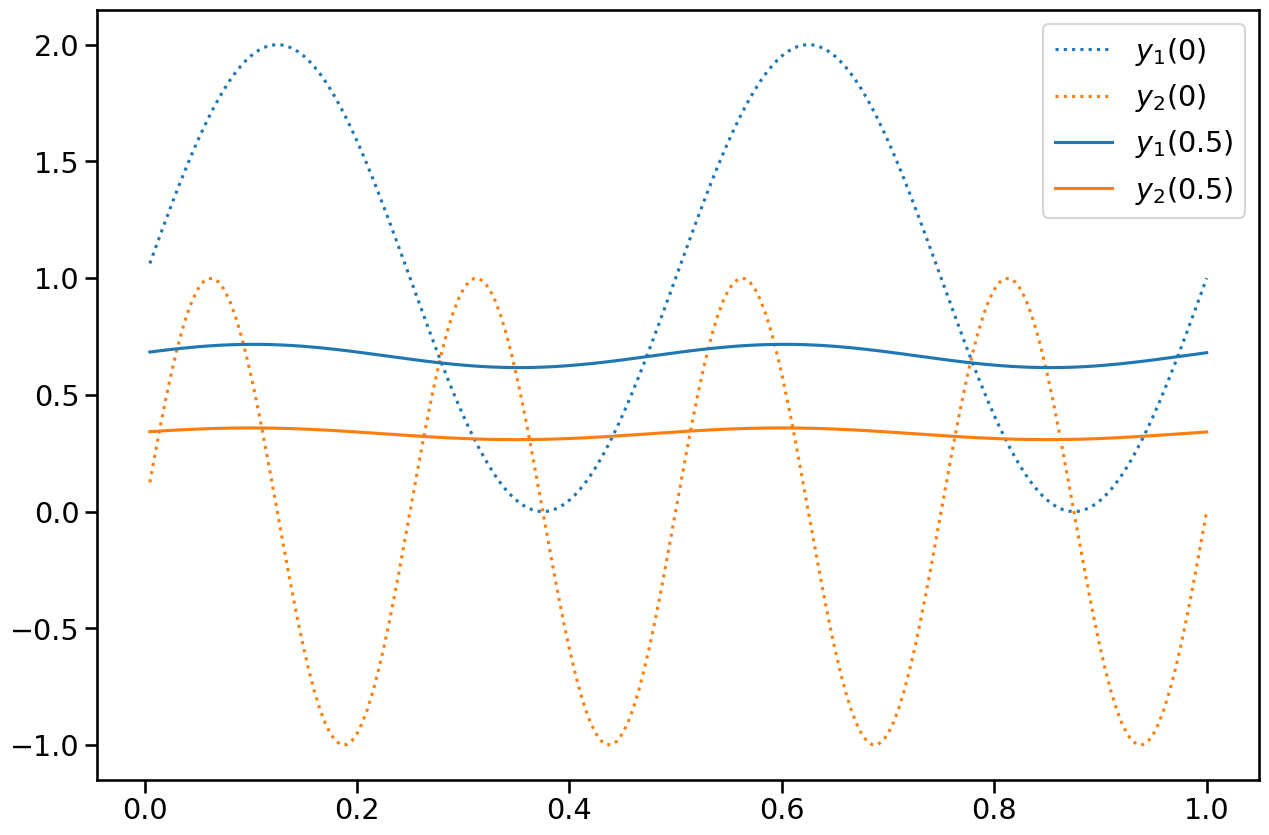

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[0.         0.         0.        ]
 [0.58578644 0.         0.        ]
 [0.5        0.5        0.        ]]
b =
[0.35355339 0.35355339 0.29289322]
c =
[0.         0.58578644 1.        ]
At =
[[0.         0.         0.        ]
 [0.         0.         0.        ]
 [1.20710678 1.20710678 1.        ]]
bt =
[0.35355339 0.35355339 0.29289322]
ct =
[0.         0.         3.41421356]
------------------------------------------


In [33]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup=pde_problem_setup_base.copy()

rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)

solver.set_method('ARK-IMEX-Mix-2-1-c')
#solver.set_method('ARK2e')
#solver.set_method('ARK-IMEX-MR4')
#solver.set_method('ARK-IMEX-Mix-1-1')


if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.005    
problem_setup['T_DURATION']['end']=TEND

CFL=[]
CFL.append(pde_problem_setup['alpha']*problem_setup['DT']/problem_setup['context']['dx'])
CFL.append(pde_problem_setup['alpha_i']*problem_setup['DT']/problem_setup['context']['dx'])
print("CFL explicit = {:}".format(CFL[0]))
print("CFL implicit = {:}".format(CFL[1]))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,_,_,_=solver.get_trajectory_GLEE()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))



#sol=u
unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))
y_end_mix21c=y_end.copy()
mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
hy1=plt.plot(x_coord,y_ini[0,:],':',label=r'$y_1(0)$')
hy2=plt.plot(x_coord,y_ini[1,:],':',label=r'$y_2(0)$')

plt.plot(x_coord,y_end[0,:],'-',color=hy1[0].get_color(),label=r'$y_1({:g})$'.format(t[-1]))
plt.plot(x_coord,y_end[1,:],'-',color=hy2[0].get_color(),label=r'$y_2({:g})$'.format(t[-1]))

plt.legend()
plt.show()

solver.view_complete_status()

ARK21c={'x_coord':x_coord,'y_end':y_end}


CFL explicit = [1. 0.]
CFL implicit = [ 0. 10.]
Solving Advection Reaction 1D by using ARK2c
Mass ini = 0.9999999999999997 and mass end = 1.000000000000006


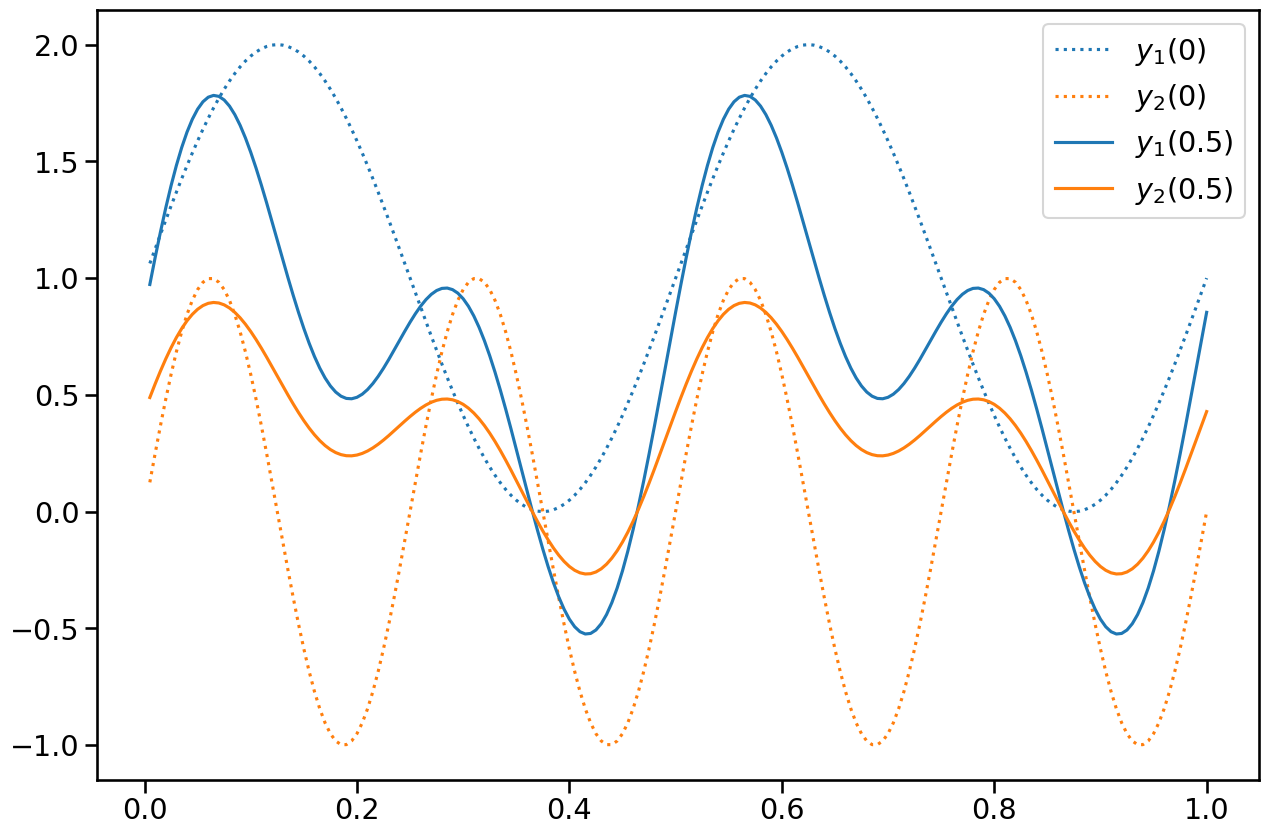

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[0.         0.         0.        ]
 [0.58578644 0.         0.        ]
 [0.5        0.5        0.        ]]
b =
[0.35355339 0.35355339 0.29289322]
c =
[0.         0.58578644 1.        ]
At =
[[0.         0.         0.        ]
 [0.29289322 0.29289322 0.        ]
 [0.35355339 0.35355339 0.29289322]]
bt =
[0.35355339 0.35355339 0.29289322]
ct =
[0.         0.58578644 1.        ]
------------------------------------------


In [34]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup=pde_problem_setup_base.copy()

rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)


solver.set_method('ARK2c')
#solver.set_method('ARK-IMEX-MR4')
#solver.set_method('ARK-IMEX-Mix-1-1')


if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.005    
problem_setup['T_DURATION']['end']=TEND

CFL=[]
CFL.append(pde_problem_setup['alpha']*problem_setup['DT']/problem_setup['context']['dx'])
CFL.append(pde_problem_setup['alpha_i']*problem_setup['DT']/problem_setup['context']['dx'])
print("CFL explicit = {:}".format(CFL[0]))
print("CFL implicit = {:}".format(CFL[1]))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,_,_,_=solver.get_trajectory_GLEE()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))



#sol=u
unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

y_end_2c=y_end.copy()

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
hy1=plt.plot(x_coord,y_ini[0,:],':',label=r'$y_1(0)$')
hy2=plt.plot(x_coord,y_ini[1,:],':',label=r'$y_2(0)$')

plt.plot(x_coord,y_end[0,:],'-',color=hy1[0].get_color(),label=r'$y_1({:g})$'.format(t[-1]))
plt.plot(x_coord,y_end[1,:],'-',color=hy2[0].get_color(),label=r'$y_2({:g})$'.format(t[-1]))

plt.legend()
plt.show()

solver.view_complete_status()

ARK2c={'x_coord':x_coord,'y_end':y_end}


CFL explicit = [1. 0.]
CFL implicit = [ 0. 10.]
Solving Advection Reaction 1D by using ARK3
Mass ini = 0.9999999999999997 and mass end = 0.9999999999999992


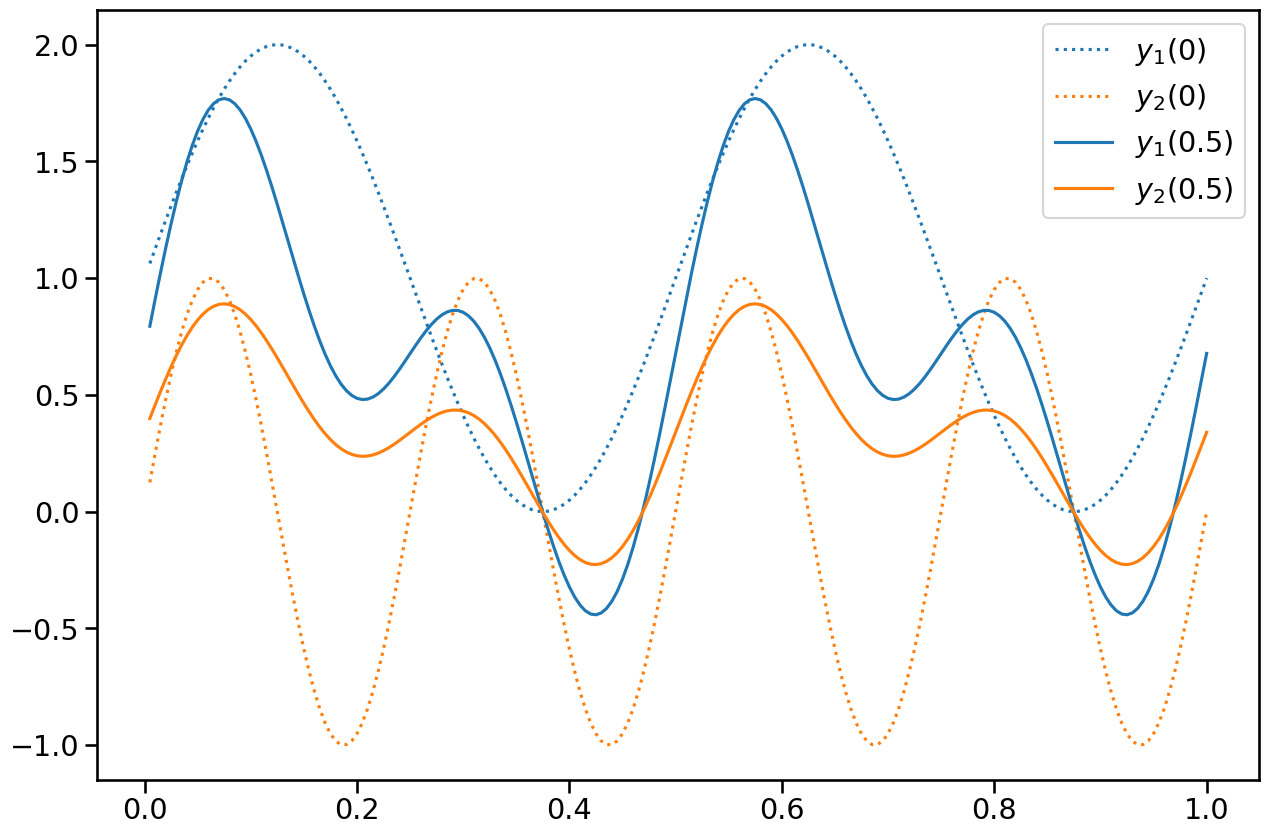

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[ 0.          0.          0.          0.        ]
 [ 0.87173304  0.          0.          0.        ]
 [ 0.52758901  0.07241099  0.          0.        ]
 [ 0.39909601 -0.43755765  1.03846165  0.        ]]
b =
[ 0.18764102 -0.59529747  0.97178993  0.43586652]
c =
[0.         0.87173304 0.6        1.        ]
At =
[[ 0.          0.          0.          0.        ]
 [ 0.43586652  0.43586652  0.          0.        ]
 [ 0.25764825 -0.09351477  0.43586652  0.        ]
 [ 0.18764102 -0.59529747  0.97178993  0.43586652]]
bt =
[ 0.18764102 -0.59529747  0.97178993  0.43586652]
ct =
[0.         0.87173304 0.6        1.        ]
------------------------------------------


In [35]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup=pde_problem_setup_base.copy()

rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)

solver.set_method('ARK3')
#solver.set_method('ARK2e')
#solver.set_method('ARK-IMEX-MR4')
#solver.set_method('ARK-IMEX-Mix-1-1')


if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.005    
problem_setup['T_DURATION']['end']=TEND

CFL=[]
CFL.append(pde_problem_setup['alpha']*problem_setup['DT']/problem_setup['context']['dx'])
CFL.append(pde_problem_setup['alpha_i']*problem_setup['DT']/problem_setup['context']['dx'])
print("CFL explicit = {:}".format(CFL[0]))
print("CFL implicit = {:}".format(CFL[1]))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,_,_,_=solver.get_trajectory_GLEE()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))



#sol=u
unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))
y_end_ark3=y_end.copy()
mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
hy1=plt.plot(x_coord,y_ini[0,:],':',label=r'$y_1(0)$')
hy2=plt.plot(x_coord,y_ini[1,:],':',label=r'$y_2(0)$')

plt.plot(x_coord,y_end[0,:],'-',color=hy1[0].get_color(),label=r'$y_1({:g})$'.format(t[-1]))
plt.plot(x_coord,y_end[1,:],'-',color=hy2[0].get_color(),label=r'$y_2({:g})$'.format(t[-1]))

plt.legend()
plt.show()

solver.view_complete_status()

ARK3={'x_coord':x_coord,'y_end':y_end}


CFL explicit = [0.2 0. ]
CFL implicit = [0. 2.]
Solving Advection Reaction 1D by using ARK3
Mass ini = 0.9999999999999997 and mass end = 0.9999999999999979


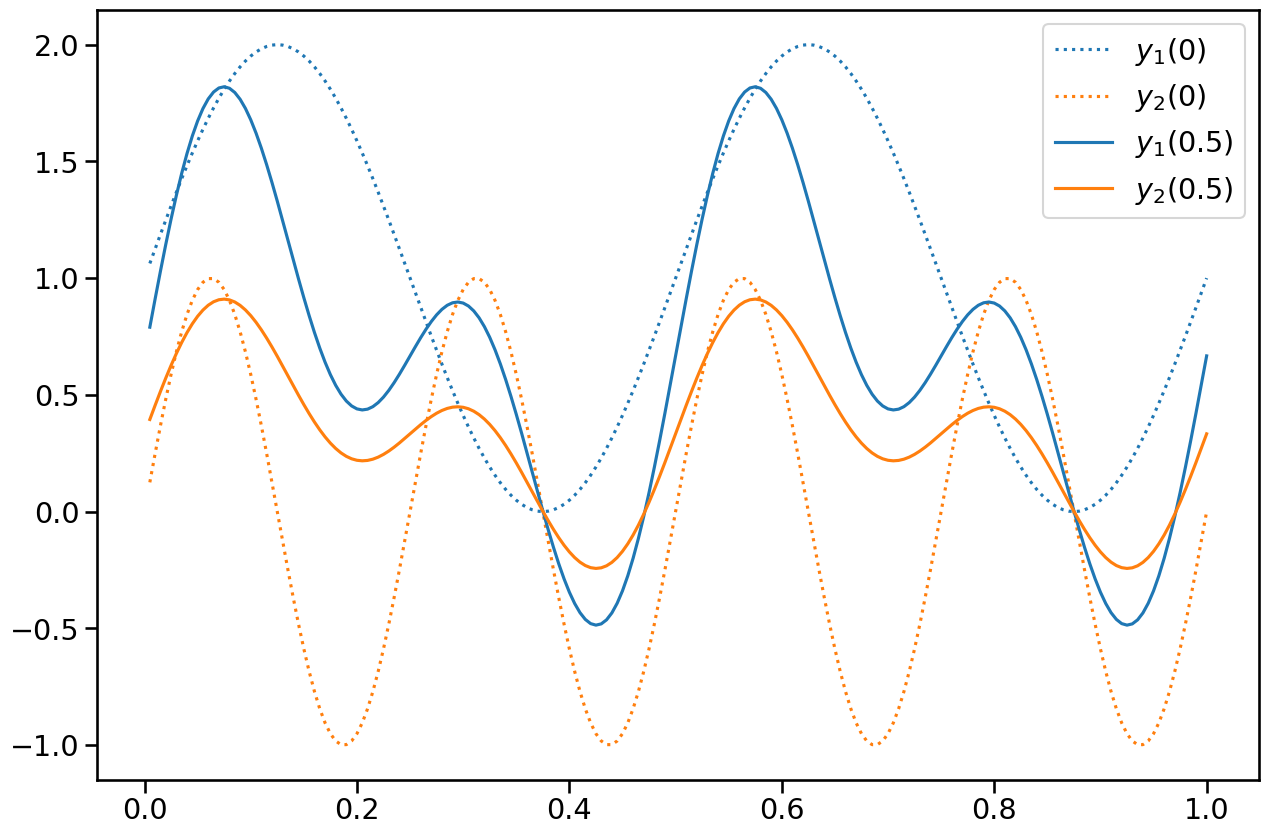

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[ 0.          0.          0.          0.        ]
 [ 0.87173304  0.          0.          0.        ]
 [ 0.52758901  0.07241099  0.          0.        ]
 [ 0.39909601 -0.43755765  1.03846165  0.        ]]
b =
[ 0.18764102 -0.59529747  0.97178993  0.43586652]
c =
[0.         0.87173304 0.6        1.        ]
At =
[[ 0.          0.          0.          0.        ]
 [ 0.43586652  0.43586652  0.          0.        ]
 [ 0.25764825 -0.09351477  0.43586652  0.        ]
 [ 0.18764102 -0.59529747  0.97178993  0.43586652]]
bt =
[ 0.18764102 -0.59529747  0.97178993  0.43586652]
ct =
[0.         0.87173304 0.6        1.        ]
------------------------------------------


In [40]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup=pde_problem_setup_base.copy()

rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)

solver.set_method('ARK3')
#solver.set_method('ARK2e')
#solver.set_method('ARK-IMEX-MR4')
#solver.set_method('ARK-IMEX-Mix-1-1')


if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.001    
problem_setup['T_DURATION']['end']=TEND

CFL=[]
CFL.append(pde_problem_setup['alpha']*problem_setup['DT']/problem_setup['context']['dx'])
CFL.append(pde_problem_setup['alpha_i']*problem_setup['DT']/problem_setup['context']['dx'])
print("CFL explicit = {:}".format(CFL[0]))
print("CFL implicit = {:}".format(CFL[1]))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,_,_,_=solver.get_trajectory_GLEE()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))



#sol=u
unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))
y_end_ark3=y_end.copy()
mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
hy1=plt.plot(x_coord,y_ini[0,:],':',label=r'$y_1(0)$')
hy2=plt.plot(x_coord,y_ini[1,:],':',label=r'$y_2(0)$')

plt.plot(x_coord,y_end[0,:],'-',color=hy1[0].get_color(),label=r'$y_1({:g})$'.format(t[-1]))
plt.plot(x_coord,y_end[1,:],'-',color=hy2[0].get_color(),label=r'$y_2({:g})$'.format(t[-1]))

plt.legend()
plt.show()

solver.view_complete_status()

ARK3fine={'x_coord':x_coord,'y_end':y_end}


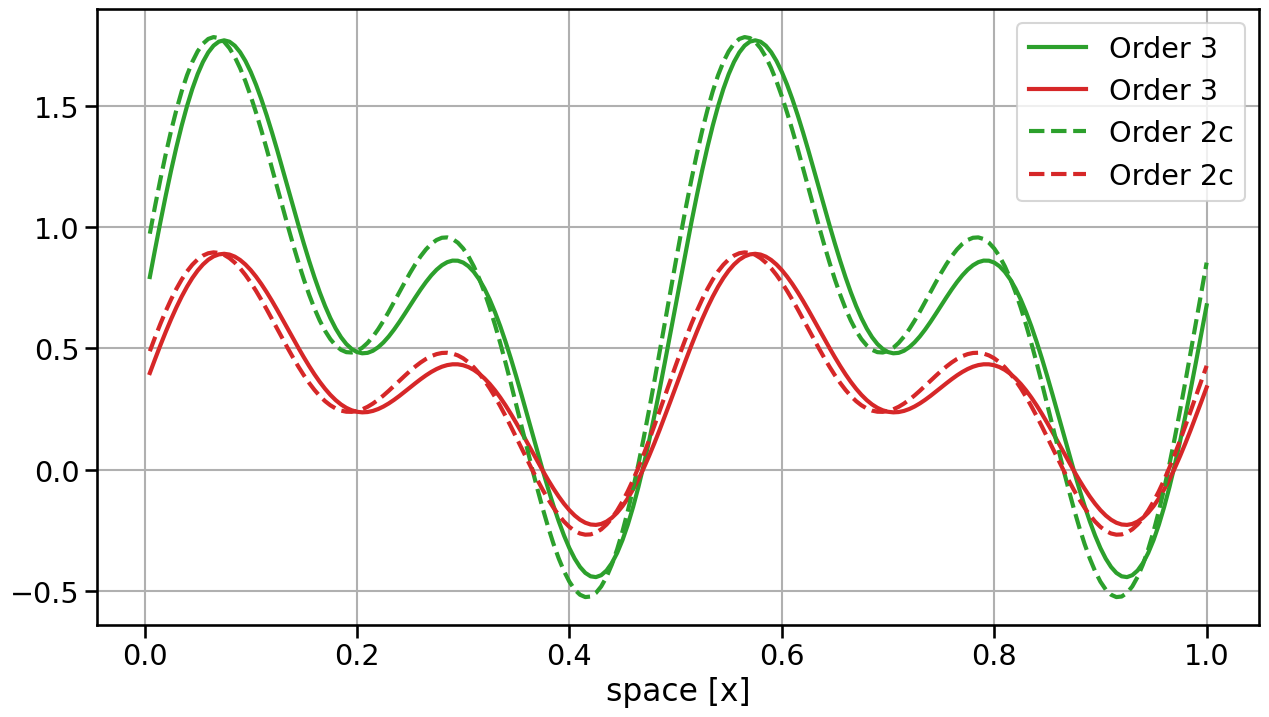

In [39]:
x_coord=ARK3['x_coord']

fig = plt.figure(figsize=(15, 8))
#plt.plot(x_coord,y_ini[0,:],':',label=r'$y_1(0)$')
#hy2=plt.plot(x_coord,y_ini[1,:],':',label=r'$y_2(0)$')

hy1=plt.plot(x_coord,ARK3['y_end'][0,:],'-',color=sns.palettes.color_palette()[2],lw=3,label=r'Order 3'.format(t[-1]))
hy2=plt.plot(x_coord,ARK3['y_end'][1,:],'-',color=sns.palettes.color_palette()[3],lw=3,label=r'Order 3'.format(t[-1]))

hy1=plt.plot(x_coord,ARK2c['y_end'][0,:],'--',color=sns.palettes.color_palette()[2],lw=3,label=r'Order 2c'.format(t[-1]))
hy2=plt.plot(x_coord,ARK2c['y_end'][1,:],'--',color=sns.palettes.color_palette()[3],lw=3,label=r'Order 2c'.format(t[-1]))


plt.xlabel('space [x]')

plt.grid('both')

plt.legend()
plt.show()

In [27]:
sns.palettes.color_palette()[2]

(0.17254901960784313, 0.6274509803921569, 0.17254901960784313)

## 

In [5]:
LOAD_DATA=True
AllResults={}
Methods_Setup={}

Methods_To_Test=['RK4','ARK2c','ARK3','ARK2e',
                 'ARK-IMEX-Mix-2-1',
                 'ARK-IMEX-Mix-3-1','ARK-IMEX-Mix-2-2',
                 'ARK-IMEX-Mix-2-2-c','ARK-IMEX-Mix-2-1-c']

Methods_To_Test=['RK4','ARK2c','ARK-IMEX-Mix-2-2-c','ARK-IMEX-Mix-2-1-c']


Methods_Setup['RK4']={'grid':{'start_exponent':-4.5, 'end_exponent':-3 , 'points':20},
                      'method':'RK4',
                      'method_ref':'RK4',
                      'dt_ref':0.00001,
                     }
Methods_Setup['ARK2e']={'grid':{'start_exponent':-4, 'end_exponent':-0.5 , 'points':20},
                      'method':'ARK2e',
                      'method_ref':'RK4',
                      'dt_ref':None,
                     }

Methods_Setup['ARKV10']={'grid':{'start_exponent':-4, 'end_exponent':-0.5 , 'points':20},
                      'method':'ARKV10',
                      'method_ref':'RK4',
                      'dt_ref':None,
                     }

Methods_Setup['ARK2c']={'grid':{'start_exponent':-4, 'end_exponent':-0.5 , 'points':20},
                      'method':'ARK2c',
                      'method_ref':'RK4',
                      'dt_ref':None,
                     }

Methods_Setup['ARK-IMEX-Mix-2-1']={'grid':{'start_exponent':-4, 'end_exponent':-0.5 , 'points':20},
                      'method':'ARK-IMEX-Mix-2-1',
                      'method_ref':'RK4',
                      'dt_ref':None,
                     }


Methods_Setup['ARK-IMEX-Mix-2-2']={'grid':{'start_exponent':-4, 'end_exponent':-0.5 , 'points':20},
                      'method':'ARK-IMEX-Mix-2-2',
                      'method_ref':'RK4',
                      'dt_ref':None,
                     }

Methods_Setup['ARK-IMEX-Mix-2-2-c']={'grid':{'start_exponent':-4, 'end_exponent':-0.5 , 'points':20},
                      'method':'ARK-IMEX-Mix-2-2-c',
                      'method_ref':'RK4',
                      'dt_ref':None,
                     }

Methods_Setup['ARK-IMEX-Mix-2-1-c']={'grid':{'start_exponent':-4, 'end_exponent':-0.5 , 'points':20},
                      'method':'ARK-IMEX-Mix-2-1-c',
                      'method_ref':'RK4',
                      'dt_ref':None,
                     }

Methods_Setup['ARK3']={'grid':{'start_exponent':-4, 'end_exponent':-0.5, 'points':20},
                      'method':'ARK3',
                      'method_ref':'RK4',
                      'dt_ref':None,
                      }

Methods_Setup['ARK-IMEX-Mix-4-1']={'grid':{'start_exponent':-4, 'end_exponent':-0.5 , 'points':20},
                      'method':'ARK-IMEX-Mix-4-1',
                      'method_ref':'RK4',
                      'dt_ref':None,
                     }

Methods_Setup['ARK-IMEX-Mix-3-1']={'grid':{'start_exponent':-4, 'end_exponent':-0.5 , 'points':20},
                      'method':'ARK-IMEX-Mix-3-1',
                      'method_ref':'RK4',
                      'dt_ref':None,
                     }

Methods_Setup['ARK-IMEX-MPRK-BE']={'grid':{'start_exponent':-4, 'end_exponent':-0.5 , 'points':20},
                      'method':'ARK-IMEX-MPRK-BE',
                      'method_ref':'RK4',
                      'dt_ref':None,
                     }

Methods_Setup['ARK-IMEX-MPRK-BASE']={'grid':{'start_exponent':-4, 'end_exponent':-0.5 , 'points':20},
                      'method':'ARK-IMEX-MPRK-BASE',
                      'method_ref':'RK4',
                      'dt_ref':None,
                     }

Methods_Setup['ARK4']={'grid':{'start_exponent':-4, 'end_exponent':-0.5, 'points':20},
                      'method':'ARK4',
                      'method_ref':'RK4',
                      'dt_ref':None,
                     }

for MethodName in Methods_To_Test:
    FN=FN_BASE+MethodName+'.pcl'
    solver=DESolver()
    solver.set_info(0)

    pde_problem_setup=pde_problem_setup_base.copy()

    rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D',pde_problem_setup)#('Navier-Stokes2D')

    solver.setup(keep_history=True)
    solver.set_function_context(problem_setup['context'])
    solver.set_initial_solution(u_ini)


    if(rhs_i is not None):
        solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
    else:
        solver.set_rhs(rhs_e)

    problem_setup['T_DURATION']['end']=TEND
    interval = {'t_start':0,'t_end': TEND}
    grid = Methods_Setup[MethodName]['grid']
    method = Methods_Setup[MethodName]['method']
    method_ref = Methods_Setup[MethodName]['method_ref']
    dt_ref = Methods_Setup[MethodName]['dt_ref']

    if (os.path.exists(FN) and LOAD_DATA):
        print("File {:} exists; loading it.".format(FN))
        AllResults[MethodName] = pickle.load( open( FN, "rb" ) )
    else:
        if(not LOAD_DATA):
            print('Re-running all simulations. Resetting!')
        if(method==method_ref):
            RSol=None
        else:
            RSol=AllResults[method_ref]['RS']
        dt_tab, sol_t, sol_u, sol_uf, sol_tf, err_tab_tf, sol_glee, sol_gleef, RS , el, uh,uhf = solver.grid_convergence(rhs_e, 
                                                                                                            rhs_i,
                                                                                                            u_ini, 
                                                                                                            problem_setup, 
                                                                                                            problem, 
                                                                                                            method, 
                                                                                                            interval, 
                                                                                                            grid, 
                                                                                                            method_ref, 
                                                                                                            dt_ref,  
                                                                                                            RefSol=RSol)

        AllResults[MethodName]={'dt_tab':dt_tab, 
                         'sol_uf':sol_uf, 
                         'sol_u':sol_u, 
                         'sol_t':sol_t, 
                         'sol_el':el, 
                         'sol_uh':uh,
                         'sol_uhf':uhf,
                         'sol_glee':sol_glee,
                         'sol_gleef':sol_gleef,
                         'err_tab_tf':err_tab_tf, 
                         'sol_gleef':sol_gleef, 
                         'RS':RS, 'method':method}

        pickle.dump(AllResults[MethodName], open( FN, "wb" ) )


Reference solution is not provided. Need to compute a reference solution first.
Solving Advection Reaction 1D by using RK4 and using a time step of 1e-05 (50000 steps)


/Users/emconsta/Research/REPO/desolve/desolve/problems_PDEs.py:1075: RuntimeWarning: overflow encountered in matmul
  F[:,id_mx]=np.matmul(K,y[:,id_mx])
/Users/emconsta/Research/REPO/desolve/desolve/problems_PDEs.py:1143: RuntimeWarning: overflow encountered in add
  u_out=vec(F+Flux,ctx)
/Users/emconsta/Research/REPO/desolve/desolve/DESolver.py:223: RuntimeWarning: overflow encountered in add
  u_out = u_ex+u_im
/Users/emconsta/Research/REPO/desolve/desolve/problems_PDEs.py:119: RuntimeWarning: invalid value encountered in double_scalars
  F[id_n,id_mx]=c[id_n,id_mx+2]*(omega_jm1+(omega_jm1-omega_jm2)*(1.-kappa)/4.+(omega_j-omega_jm1)*(1.+kappa)/4.)


Solving Advection Reaction 1D by using RK4 and using a time step of 3.162355322244007e-05 (15811 steps)


/Users/emconsta/Research/REPO/desolve/desolve/DESolver.py:838: RuntimeWarning: invalid value encountered in multiply
  dt*A[istage, jstage]*Kstage[0:n, jstage]
/Users/emconsta/Research/REPO/desolve/desolve/problems_PDEs.py:132: RuntimeWarning: invalid value encountered in subtract
  Flux[:,id_mx]=-(1./dx)*(F[:,id_mx+1]-F[:,id_mx])
/Users/emconsta/Research/REPO/desolve/desolve/problems_PDEs.py:1143: RuntimeWarning: invalid value encountered in add
  u_out=vec(F+Flux,ctx)


Solving Advection Reaction 1D by using RK4 and using a time step of 3.792763407418645e-05 (13183 steps)
Solving Advection Reaction 1D by using RK4 and using a time step of 4.5487627365356625e-05 (10992 steps)
Solving Advection Reaction 1D by using RK4 and using a time step of 5.455537370430988e-05 (9165 steps)
Solving Advection Reaction 1D by using RK4 and using a time step of 6.542789845590159e-05 (7642 steps)
Solving Advection Reaction 1D by using RK4 and using a time step of 7.848061528802385e-05 (6371 steps)
Solving Advection Reaction 1D by using RK4 and using a time step of 9.412650602409639e-05 (5312 steps)
Solving Advection Reaction 1D by using RK4 and using a time step of 0.00011289230074508918 (4429 steps)
Solving Advection Reaction 1D by using RK4 and using a time step of 0.00013539128080151638 (3693 steps)
Solving Advection Reaction 1D by using RK4 and using a time step of 0.00016239038648911984 (3079 steps)
Solving Advection Reaction 1D by using RK4 and using a time step of

/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Solving Advection Reaction 1D by using ARK2c and using a time step of 0.0001528117359413203 (3272 steps)
Solving Advection Reaction 1D by using ARK2c and using a time step of 0.00023353573096683791 (2141 steps)
Solving Advection Reaction 1D by using ARK2c and using a time step of 0.00035688793718772306 (1401 steps)
Solving Advection Reaction 1D by using ARK2c and using a time step of 0.0005458515283842794 (916 steps)
Solving Advection Reaction 1D by using ARK2c and using a time step of 0.0008333333333333334 (600 steps)
Solving Advection Reaction 1D by using ARK2c and using a time step of 0.0012755102040816326 (392 steps)
Solving Advection Reaction 1D by using ARK2c and using a time step of 0.0019455252918287938 (257 steps)
Solving Advection Reaction 1D by using ARK2c and using a time step of 0.002976190476190476 (168 steps)
Solving Advection Reaction 1D by using ARK2c and using a time step of 0.004545454545454545 (110 steps)
Solving Advection Reaction 1D by using ARK2c and using a time

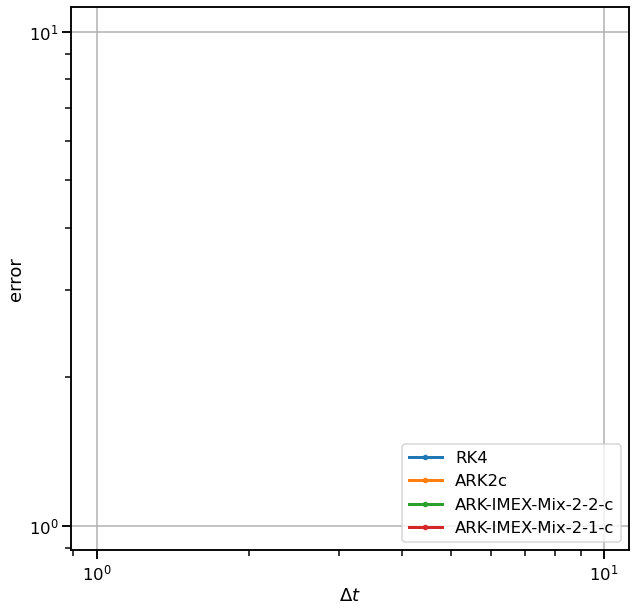

In [6]:
fig = plt.figure(figsize=(10, 10))
for MethodName in Methods_To_Test:
    plt.loglog(AllResults[MethodName]['dt_tab'],np.minimum(1e+4,AllResults[MethodName]['err_tab_tf']),'.-',lw=3,label=AllResults[MethodName]['method'])

plt.ylabel('error')
plt.xlabel(r'$\Delta t$')
plt.legend(loc='lower right')
plt.grid('both')
#plt.savefig('convergence_lorenz_uh_rk4.png')
#plt.title('Error vs time step obtained with {:}'.format(solver.get_method_name()))
plt.show()

In [7]:
Methods_To_Plot=['ARK3','ARK-IMEX-Mix-3-1']
fig = plt.figure(figsize=(10, 10))
for MethodName in Methods_To_Plot:
    plt.loglog(AllResults[MethodName]['dt_tab'],np.minimum(1e+4,AllResults[MethodName]['err_tab_tf']),'.-',lw=3,label=AllResults[MethodName]['method'])

plt.ylabel('error')
plt.xlabel(r'$\Delta t$')
plt.legend(loc='lower right')
plt.grid('both')
#plt.savefig('convergence_lorenz_uh_rk4.png')
#plt.title('Error vs time step obtained with {:}'.format(solver.get_method_name()))
plt.show()

KeyError: 'ARK3'

<Figure size 720x720 with 0 Axes>

In [ ]:
Methods_To_Plot=['ARK2c','ARK-IMEX-Mix-2-1-c']
fig = plt.figure(figsize=(10, 10))
for MethodName in Methods_To_Plot:
    plt.loglog(AllResults[MethodName]['dt_tab'],np.minimum(1e+4,AllResults[MethodName]['err_tab_tf']),'.-',lw=3,label=AllResults[MethodName]['method'])

plt.ylabel('error')
plt.xlabel(r'$\Delta t$')
plt.legend(loc='lower right')
plt.grid('both')
#plt.savefig('convergence_lorenz_uh_rk4.png')
#plt.title('Error vs time step obtained with {:}'.format(solver.get_method_name()))
plt.show()

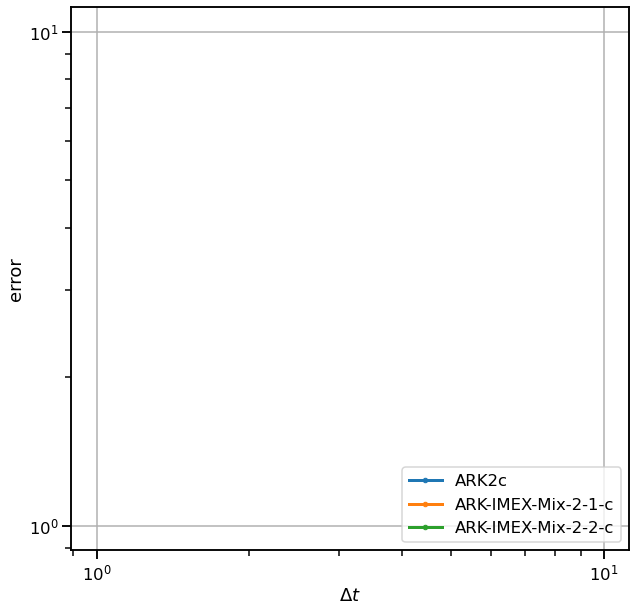

In [8]:
Methods_To_Plot=['ARK2c','ARK-IMEX-Mix-2-1-c','ARK-IMEX-Mix-2-2-c']
fig = plt.figure(figsize=(10, 10))
for MethodName in Methods_To_Plot:
    plt.loglog(AllResults[MethodName]['dt_tab'],np.minimum(1e+4,AllResults[MethodName]['err_tab_tf']),'.-',lw=3,label=AllResults[MethodName]['method'])

plt.ylabel('error')
plt.xlabel(r'$\Delta t$')
plt.legend(loc='lower right')
plt.grid('both')
#plt.savefig('convergence_lorenz_uh_rk4.png')
#plt.title('Error vs time step obtained with {:}'.format(solver.get_method_name()))
plt.show()